In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('car_insurance_claim.csv')

In [3]:
df.head()

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,...,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,...,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,...,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,...,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,...,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,"$306,251",Yes,...,Minivan,yes,$0,0,No,0,$0,6.0,0,Highly Urban/ Urban


In [4]:
df.duplicated().sum()

1

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10301 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10301 non-null  int64  
 1   KIDSDRIV    10301 non-null  int64  
 2   BIRTH       10301 non-null  object 
 3   AGE         10294 non-null  float64
 4   HOMEKIDS    10301 non-null  int64  
 5   YOJ         9753 non-null   float64
 6   INCOME      9731 non-null   object 
 7   PARENT1     10301 non-null  object 
 8   HOME_VAL    9726 non-null   object 
 9   MSTATUS     10301 non-null  object 
 10  GENDER      10301 non-null  object 
 11  EDUCATION   10301 non-null  object 
 12  OCCUPATION  9636 non-null   object 
 13  TRAVTIME    10301 non-null  int64  
 14  CAR_USE     10301 non-null  object 
 15  BLUEBOOK    10301 non-null  object 
 16  TIF         10301 non-null  int64  
 17  CAR_TYPE    10301 non-null  object 
 18  RED_CAR     10301 non-null  object 
 19  OLDCLAIM    10301 non-null  ob

In [7]:
data_df = df.copy()


In [8]:
col_names = {
    'KIDSDRIV': 'num_young_drivers',
    'BIRTH': 'date_of_birth',
    'AGE': 'age',
    'HOMEKIDS': 'num_of_children',
    'YOJ': 'years_job_held_for',
    'INCOME': 'income',
    'PARENT1': 'single_parent',
    'HOME_VAL': 'value_of_home',
    'MSTATUS': 'married',
    'GENDER': 'gender',
    'EDUCATION': 'highest_education',
    'OCCUPATION': 'occupation',
    'TRAVTIME': 'commute_dist',
    'CAR_USE': 'type_of_use',
    'BLUEBOOK': 'vehicle_value',
    'TIF': 'policy_tenure',
    'CAR_TYPE': 'vehicle_type',
    'RED_CAR': 'red_vehicle',
    'OLDCLAIM': '5_year_total_claims_value',
    'CLM_FREQ': '5_year_num_of_claims',
    'REVOKED': 'licence_revoked',
    'MVR_PTS': 'license_points',
    'CLM_AMT': 'new_claim_value',
    'CAR_AGE': 'vehicle_age',
    'CLAIM_FLAG': 'is_claim',
    'URBANICITY': 'address_type'
}

data_df.rename(columns = col_names, inplace=True)

In [9]:
data_df.head(10)

,ID,num_young_drivers,date_of_birth,age,num_of_children,years_job_held_for,income,single_parent,value_of_home,married,...,vehicle_type,red_vehicle,5_year_total_claims_value,5_year_num_of_claims,licence_revoked,license_points,new_claim_value,vehicle_age,is_claim,address_type
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,...,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,...,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,...,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,...,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,"$306,251",Yes,...,Minivan,yes,$0,0,No,0,$0,6.0,0,Highly Urban/ Urban
5,743146596,0,17MAY49,50.0,0,NaN,"$114,986",No,"$243,925",Yes,...,z_SUV,no,"$19,217",2,Yes,3,$0,17.0,0,Highly Urban/ Urban
6,871024631,0,05MAY65,34.0,1,12.0,"$125,301",Yes,$0,z_No,...,Sports Car,no,$0,0,No,0,"$2,946",7.0,1,Highly Urban/ Urban
7,792300541,0,28FEB45,54.0,0,NaN,"$18,755",No,NaN,Yes,...,z_SUV,no,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
8,7945239,1,17SEP59,40.0,1,11.0,"$50,815",Yes,$0,z_No,...,Minivan,no,"$3,295",1,No,2,"$6,477",1.0,1,Highly Urban/ Urban
9,3577610,0,21AUG55,44.0,2,12.0,"$43,486",Yes,$0,z_No,...,z_SUV,no,$0,0,No,0,$0,10.0,0,z_Highly Rural/ Rural


In [10]:
currency_cols = ['income', 'value_of_home', 'vehicle_value', '5_year_total_claims_value', 'new_claim_value']

def format_currency_data_cols(data_df, cols):
        for col in currency_cols:
            data_df[col] = data_df[col].replace('[\\$,]', '', regex=True).astype('Int64')
        return data_df

data_df = format_currency_data_cols(data_df, currency_cols)

In [11]:
cols_with_z_prefix = []

for col in data_df.columns:
    if data_df[col].dtype == 'object':
        if data_df[col].str.startswith('z_').any():
            cols_with_z_prefix.append(col)

In [12]:
cols_with_z_prefix

['married',
 'gender',
 'highest_education',
 'occupation',
 'vehicle_type',
 'address_type']

In [13]:
def drop_z_prefix_cols(data_df, cols):
    for col in cols:
        data_df[col] = data_df[col].replace('[z_]', '', regex = True)
    return data_df

data_df = drop_z_prefix_cols(data_df, cols_with_z_prefix)

In [14]:
data_df.head()

,ID,num_young_drivers,date_of_birth,age,num_of_children,years_job_held_for,income,single_parent,value_of_home,married,...,vehicle_type,red_vehicle,5_year_total_claims_value,5_year_num_of_claims,licence_revoked,license_points,new_claim_value,vehicle_age,is_claim,address_type
0,63581743,0,16MAR39,60.0,0,11.0,67349,No,0,No,...,Minivan,yes,4461,2,No,3,0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,91449,No,257252,No,...,Minivan,yes,0,0,No,0,0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,52881,No,0,No,...,Van,yes,0,0,No,2,0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,16039,No,124191,Yes,...,SUV,no,38690,2,No,3,0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,<NA>,No,306251,Yes,...,Minivan,yes,0,0,No,0,0,6.0,0,Highly Urban/ Urban


In [15]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10301 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         10301 non-null  int64  
 1   num_young_drivers          10301 non-null  int64  
 2   date_of_birth              10301 non-null  object 
 3   age                        10294 non-null  float64
 4   num_of_children            10301 non-null  int64  
 5   years_job_held_for         9753 non-null   float64
 6   income                     9731 non-null   Int64  
 7   single_parent              10301 non-null  object 
 8   value_of_home              9726 non-null   Int64  
 9   married                    10301 non-null  object 
 10  gender                     10301 non-null  object 
 11  highest_education          10301 non-null  object 
 12  occupation                 9636 non-null   object 
 13  commute_dist               10301 non-null  int64  


In [16]:
data_df.drop(columns=['date_of_birth', 'ID'], inplace=True)

In [17]:
mask = (data_df['new_claim_value'] > 0) & (data_df['is_claim'] == 0)
data_df[mask]

,num_young_drivers,age,num_of_children,years_job_held_for,income,single_parent,value_of_home,married,gender,highest_education,...,vehicle_type,red_vehicle,5_year_total_claims_value,5_year_num_of_claims,licence_revoked,license_points,new_claim_value,vehicle_age,is_claim,address_type


<Axes: xlabel='new_claim_value', ylabel='Count'>

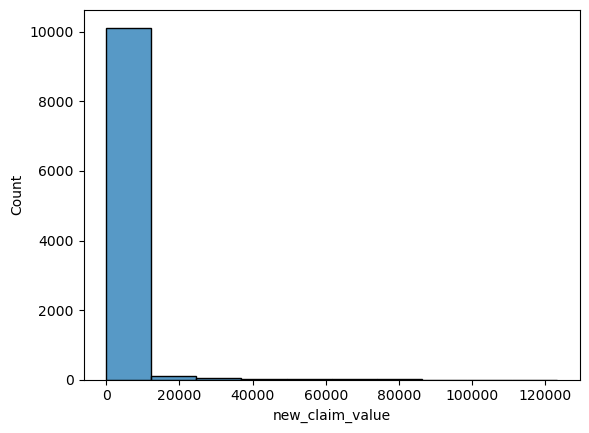

In [18]:
import seaborn as sns

sns.histplot(data_df['new_claim_value'], bins=10)

In [19]:
bins = [0.0, 5000, 10_000, 15_000, 20_000, 25_000, 30_000, 35_000, 40_000, 45_000, 50_000, np.inf]

labels = np.arange(1, 12)

data_df['claim_value_cat'] = pd.cut(data_df['new_claim_value'], bins = bins, labels= labels, include_lowest=True)

<Axes: ylabel='claim_value_cat'>

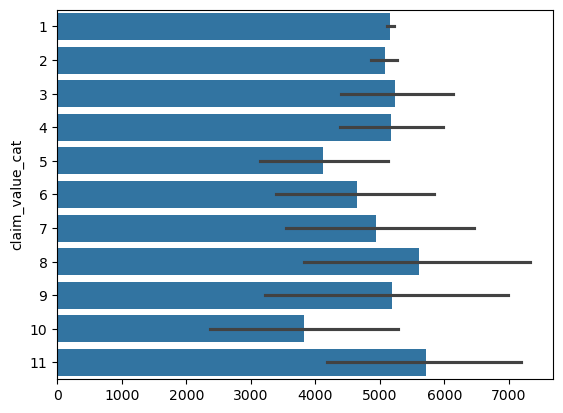

In [20]:
sns.barplot(data_df['claim_value_cat'])

In [21]:
from sklearn.model_selection import train_test_split

X = data_df.copy()
y = data_df['is_claim']

X.drop(columns = ['new_claim_value', 'is_claim'], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = X['claim_value_cat'])

In [22]:
train_ratio = round(y_train.sum()/len(y_train)*100,2)
test_ratio = round(y_test.sum()/len(y_test)*100,2)

print(f'Training set claim ratio: {train_ratio}%')
print(f'Testing set claim ratio: {test_ratio}%')

Training set claim ratio: 26.48%
Testing set claim ratio: 27.37%


In [23]:
# remove bins for each set

for set_ in (X_train, X_test):
    set_.drop(columns = ['claim_value_cat'], inplace=True)

### EDA

### PREPARATION

In [24]:
data_df.head()

,num_young_drivers,age,num_of_children,years_job_held_for,income,single_parent,value_of_home,married,gender,highest_education,...,red_vehicle,5_year_total_claims_value,5_year_num_of_claims,licence_revoked,license_points,new_claim_value,vehicle_age,is_claim,address_type,claim_value_cat
0,0,60.0,0,11.0,67349,No,0,No,M,PhD,...,yes,4461,2,No,3,0,18.0,0,Highly Urban/ Urban,1
1,0,43.0,0,11.0,91449,No,257252,No,M,High School,...,yes,0,0,No,0,0,1.0,0,Highly Urban/ Urban,1
2,0,48.0,0,11.0,52881,No,0,No,M,Bachelors,...,yes,0,0,No,2,0,10.0,0,Highly Urban/ Urban,1
3,0,35.0,1,10.0,16039,No,124191,Yes,F,High School,...,no,38690,2,No,3,0,10.0,0,Highly Urban/ Urban,1
4,0,51.0,0,14.0,<NA>,No,306251,Yes,M,<High School,...,yes,0,0,No,0,0,6.0,0,Highly Urban/ Urban,1


In [25]:
eda_test_data = X_train.copy()
eda_test_data['is_claim'] = y_train

In [26]:
binary_cols = ['single_parent', 'married', 'gender', 'red_vehicle', 'licence_revoked']

mapping = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'M': 1, 'F': 0}

def binarize_values(data_df, cols, map):
    for col in cols:
        data_df[col] = data_df[col].map(map)
    return data_df

eda_test_data = binarize_values(eda_test_data, binary_cols, mapping)

### 2.2 correlation matrix


In [27]:
corr_matrix = eda_test_data.corr(numeric_only=True).sort_values(by = 'is_claim', ascending = False)
corr_matrix_no_claim = corr_matrix.drop('is_claim')

<Axes: >

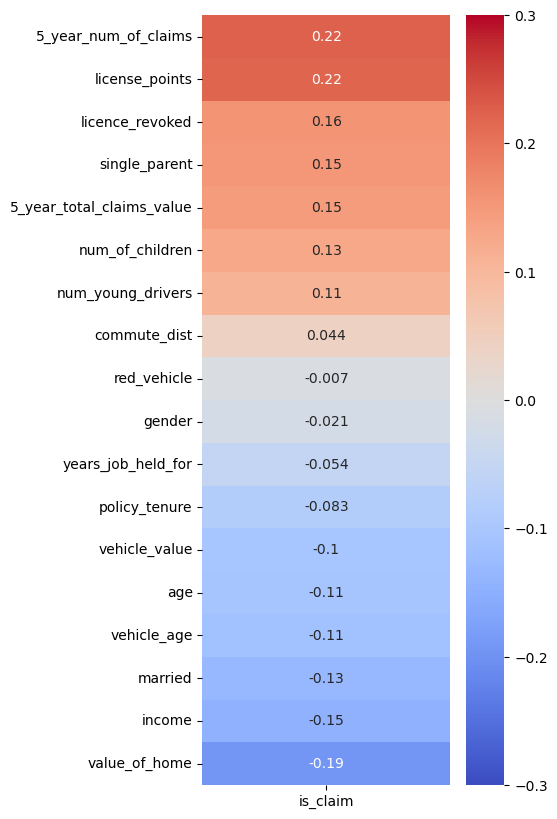

In [28]:
fig, ax = plt.subplots(figsize = (4,10))
sns.heatmap(corr_matrix_no_claim[['is_claim']], cmap = 'coolwarm', annot = True, vmax =0.3, vmin = -0.3)

### 3. Data Cleaning

#### 3.1 Dropping features

In [29]:
X_train_raw = X_train.copy()

cols_to_drop = ['red_vehicle']

X_train_raw.drop(columns = cols_to_drop, inplace = True)

In [30]:
X_train_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8240 entries, 8452 to 5211
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   num_young_drivers          8240 non-null   int64  
 1   age                        8235 non-null   float64
 2   num_of_children            8240 non-null   int64  
 3   years_job_held_for         7807 non-null   float64
 4   income                     7766 non-null   Int64  
 5   single_parent              8240 non-null   object 
 6   value_of_home              7778 non-null   Int64  
 7   married                    8240 non-null   object 
 8   gender                     8240 non-null   object 
 9   highest_education          8240 non-null   object 
 10  occupation                 7713 non-null   object 
 11  commute_dist               8240 non-null   int64  
 12  type_of_use                8240 non-null   object 
 13  vehicle_value              8240 non-null   Int64  

In [31]:
X_train_raw.isnull().sum()

num_young_drivers              0
age                            5
num_of_children                0
years_job_held_for           433
income                       474
single_parent                  0
value_of_home                462
married                        0
gender                         0
highest_education              0
occupation                   527
commute_dist                   0
type_of_use                    0
vehicle_value                  0
policy_tenure                  0
vehicle_type                   0
5_year_total_claims_value      0
5_year_num_of_claims           0
licence_revoked                0
license_points                 0
vehicle_age                  517
address_type                   0
dtype: int64

In [32]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=2)

numerical_cols = X_train_raw.select_dtypes(include=['number'])
numerical_cols = numerical_cols.columns.tolist()


cat_col_df =  X_train_raw.select_dtypes(include=['object'])

cat_cols = cat_col_df.columns.tolist()


In [33]:
def impute_num_knn(data_df, cols, imputer):
    data = data_df[cols]
    imputed_data = pd.DataFrame(imputer.fit_transform(data))
    imputed_data.columns = data.columns
    return imputed_data

imputed_num_data = impute_num_knn(X_train_raw, numerical_cols, knn_imputer)

In [34]:
# numerical cols as df
num_cols_df = X_train_raw[numerical_cols].reset_index(drop=True)

missing_data_df = num_cols_df[num_cols_df.isna().any(axis=1)]
missing_data_df.head(20)


,num_young_drivers,age,num_of_children,years_job_held_for,income,value_of_home,commute_dist,vehicle_value,policy_tenure,5_year_total_claims_value,5_year_num_of_claims,license_points,vehicle_age
0,0,57.0,0,NaN,33707,0,40,7200,10,0,0,1,1.0
11,0,36.0,2,13.0,19934,<NA>,17,10790,6,7797,2,9,1.0
19,0,59.0,0,11.0,123969,347418,35,31540,1,0,0,1,NaN
25,0,51.0,0,7.0,141546,351285,18,29330,4,1184,2,4,NaN
28,1,51.0,1,8.0,<NA>,253662,5,12430,1,9000,1,0,11.0
32,0,53.0,0,NaN,88712,239681,49,16310,13,1835,2,2,11.0
33,0,50.0,0,12.0,<NA>,0,13,32470,1,0,0,0,16.0
36,0,40.0,0,12.0,74117,252030,24,28620,1,5784,1,0,NaN
38,0,46.0,0,10.0,121840,326187,31,29300,3,0,0,1,NaN
39,0,30.0,1,10.0,18721,0,9,20650,9,0,0,0,NaN


In [35]:
# show after imputation

samples = imputed_num_data.index.to_list()
imputed_num_data.loc[samples[11]]

num_young_drivers                 0.0
age                              36.0
num_of_children                   2.0
years_job_held_for               13.0
income                        19934.0
value_of_home                158778.5
commute_dist                     17.0
vehicle_value                 10790.0
policy_tenure                     6.0
5_year_total_claims_value      7797.0
5_year_num_of_claims              2.0
license_points                    9.0
vehicle_age                       1.0
Name: 11, dtype: float64

In [36]:
# create the imputer

from sklearn.impute import SimpleImputer

simple_imputer = SimpleImputer(strategy='most_frequent')

def impute_cat_simple(data_df, cols, imputer):
    data = data_df[cols]
    imputed_data = pd.DataFrame(imputer.fit_transform(data))
    imputed_data.columns = data.columns
    return imputed_data

imputed_cat_data = impute_cat_simple(X_train_raw, cat_cols, simple_imputer)

In [37]:
cat_cols_df = X_train_raw[cat_cols].reset_index(drop = True)

missing_cat_data = cat_cols_df[num_cols_df.isna().any(axis=1)]
missing_cat_data.head(10)

,single_parent,married,gender,highest_education,occupation,type_of_use,vehicle_type,licence_revoked,address_type
0,No,No,F,<High School,Blue Collar,Private,SUV,No,Highly Rural/ Rural
11,Yes,No,M,High School,Clerical,Private,Pickup,No,Highly Urban/ Urban
19,No,Yes,M,Masters,NaN,Commercial,Panel Truck,No,Highly Urban/ Urban
25,No,No,M,PhD,Manager,Commercial,Panel Truck,No,Highly Urban/ Urban
28,No,Yes,M,High School,Blue Collar,Commercial,Minivan,No,Highly Urban/ Urban
32,No,No,F,Bachelors,Professional,Private,SUV,No,Highly Urban/ Urban
33,No,No,F,Masters,Lawyer,Private,Sports Car,No,Highly Urban/ Urban
36,No,Yes,F,Masters,NaN,Commercial,Van,No,Highly Urban/ Urban
38,No,No,F,Masters,Lawyer,Private,Sports Car,No,Highly Urban/ Urban
39,Yes,No,F,<High School,Clerical,Private,SUV,No,Highly Rural/ Rural


In [38]:
# show after imputation

samples = missing_cat_data.index.to_list()
imputed_cat_data.loc[samples].head()

,single_parent,married,gender,highest_education,occupation,type_of_use,vehicle_type,licence_revoked,address_type
0,No,No,F,<High School,Blue Collar,Private,SUV,No,Highly Rural/ Rural
11,Yes,No,M,High School,Clerical,Private,Pickup,No,Highly Urban/ Urban
19,No,Yes,M,Masters,Blue Collar,Commercial,Panel Truck,No,Highly Urban/ Urban
25,No,No,M,PhD,Manager,Commercial,Panel Truck,No,Highly Urban/ Urban
28,No,Yes,M,High School,Blue Collar,Commercial,Minivan,No,Highly Urban/ Urban


In [39]:
# rejoin df

train_imputed_df = pd.concat([imputed_num_data, imputed_cat_data], axis=1)

train_imputed_df.head()


,num_young_drivers,age,num_of_children,years_job_held_for,income,value_of_home,commute_dist,vehicle_value,policy_tenure,5_year_total_claims_value,...,vehicle_age,single_parent,married,gender,highest_education,occupation,type_of_use,vehicle_type,licence_revoked,address_type
0,0.0,57.0,0.0,0.0,33707.0,0.0,40.0,7200.0,10.0,0.0,...,1.0,No,No,F,<High School,Blue Collar,Private,SUV,No,Highly Rural/ Rural
1,2.0,41.0,3.0,14.0,17321.0,109835.0,24.0,6530.0,4.0,0.0,...,1.0,No,Yes,F,<High School,Blue Collar,Private,Sports Car,No,Highly Urban/ Urban
2,0.0,29.0,2.0,12.0,54310.0,174139.0,39.0,1500.0,4.0,5419.0,...,6.0,Yes,No,M,<High School,Clerical,Private,Minivan,No,Highly Urban/ Urban
3,0.0,46.0,1.0,13.0,62886.0,202178.0,18.0,22260.0,1.0,5290.0,...,6.0,Yes,No,F,Bachelors,Professional,Private,Minivan,No,Highly Urban/ Urban
4,0.0,39.0,0.0,8.0,115182.0,312887.0,25.0,5400.0,1.0,0.0,...,5.0,No,Yes,M,High School,Professional,Commercial,Pickup,No,Highly Urban/ Urban


In [40]:
train_imputed_df.isnull().sum().sum()

0

#### 3.4 Categorical Feature Encoding

In [41]:
imputed_cat_data.nunique()

single_parent        2
married              2
gender               2
highest_education    5
occupation           8
type_of_use          2
vehicle_type         6
licence_revoked      2
address_type         2
dtype: int64

- binary encoding
- binary encoding
- binary encoding
- ordinal encoding (rank)
- one-hot encoding (no rank)
- binary encoding 
- one-hot encoding
- binary encoding
- binary encoding

Since Scikit-Learn has no binary encoding option currently for independent features, we can use the ordinal encoder in this as we only have 2 unique values

In [42]:
cat_cols_ord = ['highest_education']

cat_cols_binary = ['single_parent', 'married', 'gender', 'type_of_use', 'licence_revoked', 'address_type']

cat_cols_one_hot = ['occupation', 'vehicle_type']

In [43]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# For the education encoder we will first need to define the order/ranking of the levels of education.
education_rank = [['<High School', 'High School', 'Bachelors', 'Masters', 'PhD']]

ord_encoder = OrdinalEncoder(categories = education_rank)
bin_encoder = OrdinalEncoder()
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [44]:
## We can now encode the values use fit_transform:

# Encode ordinals
ord_encoded = ord_encoder.fit_transform(imputed_cat_data[cat_cols_ord])

# Encode binaries
bin_encoded = bin_encoder.fit_transform(imputed_cat_data[cat_cols_binary])

# One-hot encoding
one_hot_encoded = onehot_encoder.fit_transform(imputed_cat_data[cat_cols_one_hot])

In [45]:
# return the encoded data to dataframes

ord_encoded_df = pd.DataFrame(ord_encoded, columns = cat_cols_ord)
bin_encoded_df = pd.DataFrame(bin_encoded, columns = cat_cols_binary)
one_hot_encoded_df = pd.DataFrame(one_hot_encoded, columns = onehot_encoder.get_feature_names_out())

# join all encoded data

all_cat_encoded = pd.concat([ord_encoded_df, bin_encoded_df, one_hot_encoded_df], axis=1)
all_cat_encoded.filter(like='occupation').head()
all_cat_encoded.head()


,highest_education,single_parent,married,gender,type_of_use,licence_revoked,address_type,occupation_Blue Collar,occupation_Clerical,occupation_Doctor,...,occupation_Lawyer,occupation_Manager,occupation_Professional,occupation_Student,vehicle_type_Minivan,vehicle_type_Panel Truck,vehicle_type_Pickup,vehicle_type_SUV,vehicle_type_Sports Car,vehicle_type_Van
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [46]:
# join numerical and categorical data

final_train_df = pd.concat([train_imputed_df[numerical_cols], all_cat_encoded], axis=1)
final_train_df.head()


,num_young_drivers,age,num_of_children,years_job_held_for,income,value_of_home,commute_dist,vehicle_value,policy_tenure,5_year_total_claims_value,...,occupation_Lawyer,occupation_Manager,occupation_Professional,occupation_Student,vehicle_type_Minivan,vehicle_type_Panel Truck,vehicle_type_Pickup,vehicle_type_SUV,vehicle_type_Sports Car,vehicle_type_Van
0,0.0,57.0,0.0,0.0,33707.0,0.0,40.0,7200.0,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,41.0,3.0,14.0,17321.0,109835.0,24.0,6530.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,29.0,2.0,12.0,54310.0,174139.0,39.0,1500.0,4.0,5419.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,46.0,1.0,13.0,62886.0,202178.0,18.0,22260.0,1.0,5290.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,39.0,0.0,8.0,115182.0,312887.0,25.0,5400.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [50]:
from statsmodels.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor


def calculated_vif(dataframe):
    df_with_constant = add_constant(dataframe)
    vif_data = pd.DataFrame()
    vif_data['feature'] = df_with_constant.columns
    vif_data['VIF'] = [variance_inflation_factor(df_with_constant.values, i)
                       for i in range(df_with_constant.shape[1])]
    return vif_data

vif_df = calculated_vif(final_train_df)
vif_df

/Users/rieno/Downloads/ENTER/envs/pano/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/rieno/Downloads/ENTER/envs/pano/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,const,0.000000
1,num_young_drivers,1.317458
2,age,1.470704
3,num_of_children,2.083100
4,years_job_held_for,1.437881
5,income,2.633292
6,value_of_home,2.120414
7,commute_dist,1.039162
8,vehicle_value,2.030342
9,policy_tenure,1.005861



one-hot encoded features (occupation and vehicle type) show perfect multicolinearity. 
then, we drop dummy variables from the encoded data; reference category or baseline cat


In [53]:
final_train_df.drop(columns = ['occupation_Blue Collar', 'vehicle_type_Minivan'], axis=1, inplace=True)

vif_df = calculated_vif(final_train_df)
vif_df

,feature,VIF
0,const,80.124998
1,num_young_drivers,1.317458
2,age,1.470704
3,num_of_children,2.083100
4,years_job_held_for,1.437881
5,income,2.633292
6,value_of_home,2.120414
7,commute_dist,1.039162
8,vehicle_value,2.030342
9,policy_tenure,1.005861


### 5. Model Selection


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

clfs = [
    ('Logistic Regression', LogisticRegression(solver='liblinear', max_iter=2000)),
    ('KNN', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Linear SVM', LinearSVC(random_state=42, max_iter=1000, dual='auto')),
    ('XGBoost', XGBClassifier(random_state=42)),
    ('AdaBoost', AdaBoostClassifier(random_state=42, algorithm='SAMME')),
    ('Gradient Boost', GradientBoostingClassifier(random_state=42)),
    ('Bagging', BaggingClassifier(random_state=42)),
    ('CatBoost', CatBoostClassifier(random_state=42, verbose=0)),
]

In [56]:
from sklearn.model_selection import KFold, cross_val_score

k_fold = KFold(n_splits=10, shuffle=True, random_state=42)

results = {}

#evaluate each classififier using k-fold cross-validation

for clfs_name, clf in clfs:
    cv_scores = cross_val_score(clf, final_train_df, y_train, cv = k_fold)
    results[clfs_name] = cv_scores

# display results
results_df = pd.DataFrame(results)

/Users/rieno/Downloads/ENTER/envs/pano/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/rieno/Downloads/ENTER/envs/pano/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/rieno/Downloads/ENTER/envs/pano/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/rieno/Downloads/ENTER/envs/pano/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/Users/rieno/Downloads/ENTER

Text(0.5, 1.0, 'Cross-Validation Scores for Different Classifiers')

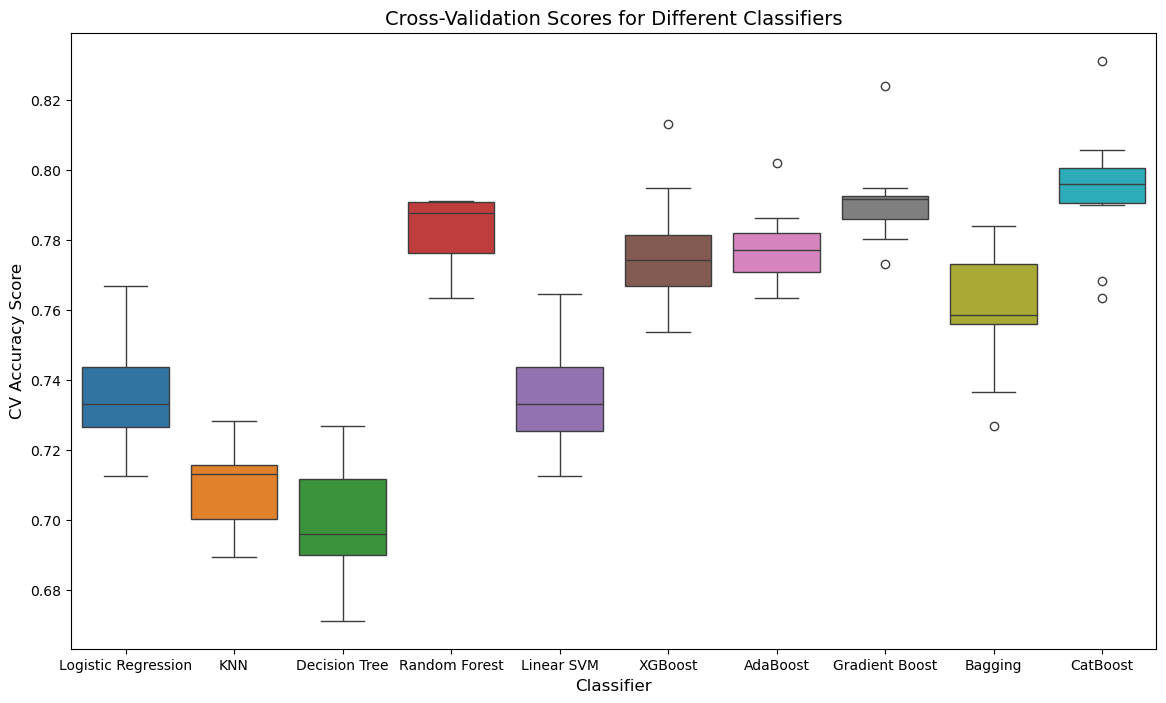

In [60]:
# plot scores

fig, ax = plt.subplots(figsize = (14,8))
sns.boxplot(results_df)

# add axis lablels 

ax.set_xlabel('Classifier', fontsize=12)
ax.set_ylabel('CV Accuracy Score', fontsize=12)
ax.set_title('Cross-Validation Scores for Different Classifiers', fontsize=14)

based on the accuracy scores, the best performing model was catboost, followed by gradient boost and random forest

### 6. Feauture Engineering

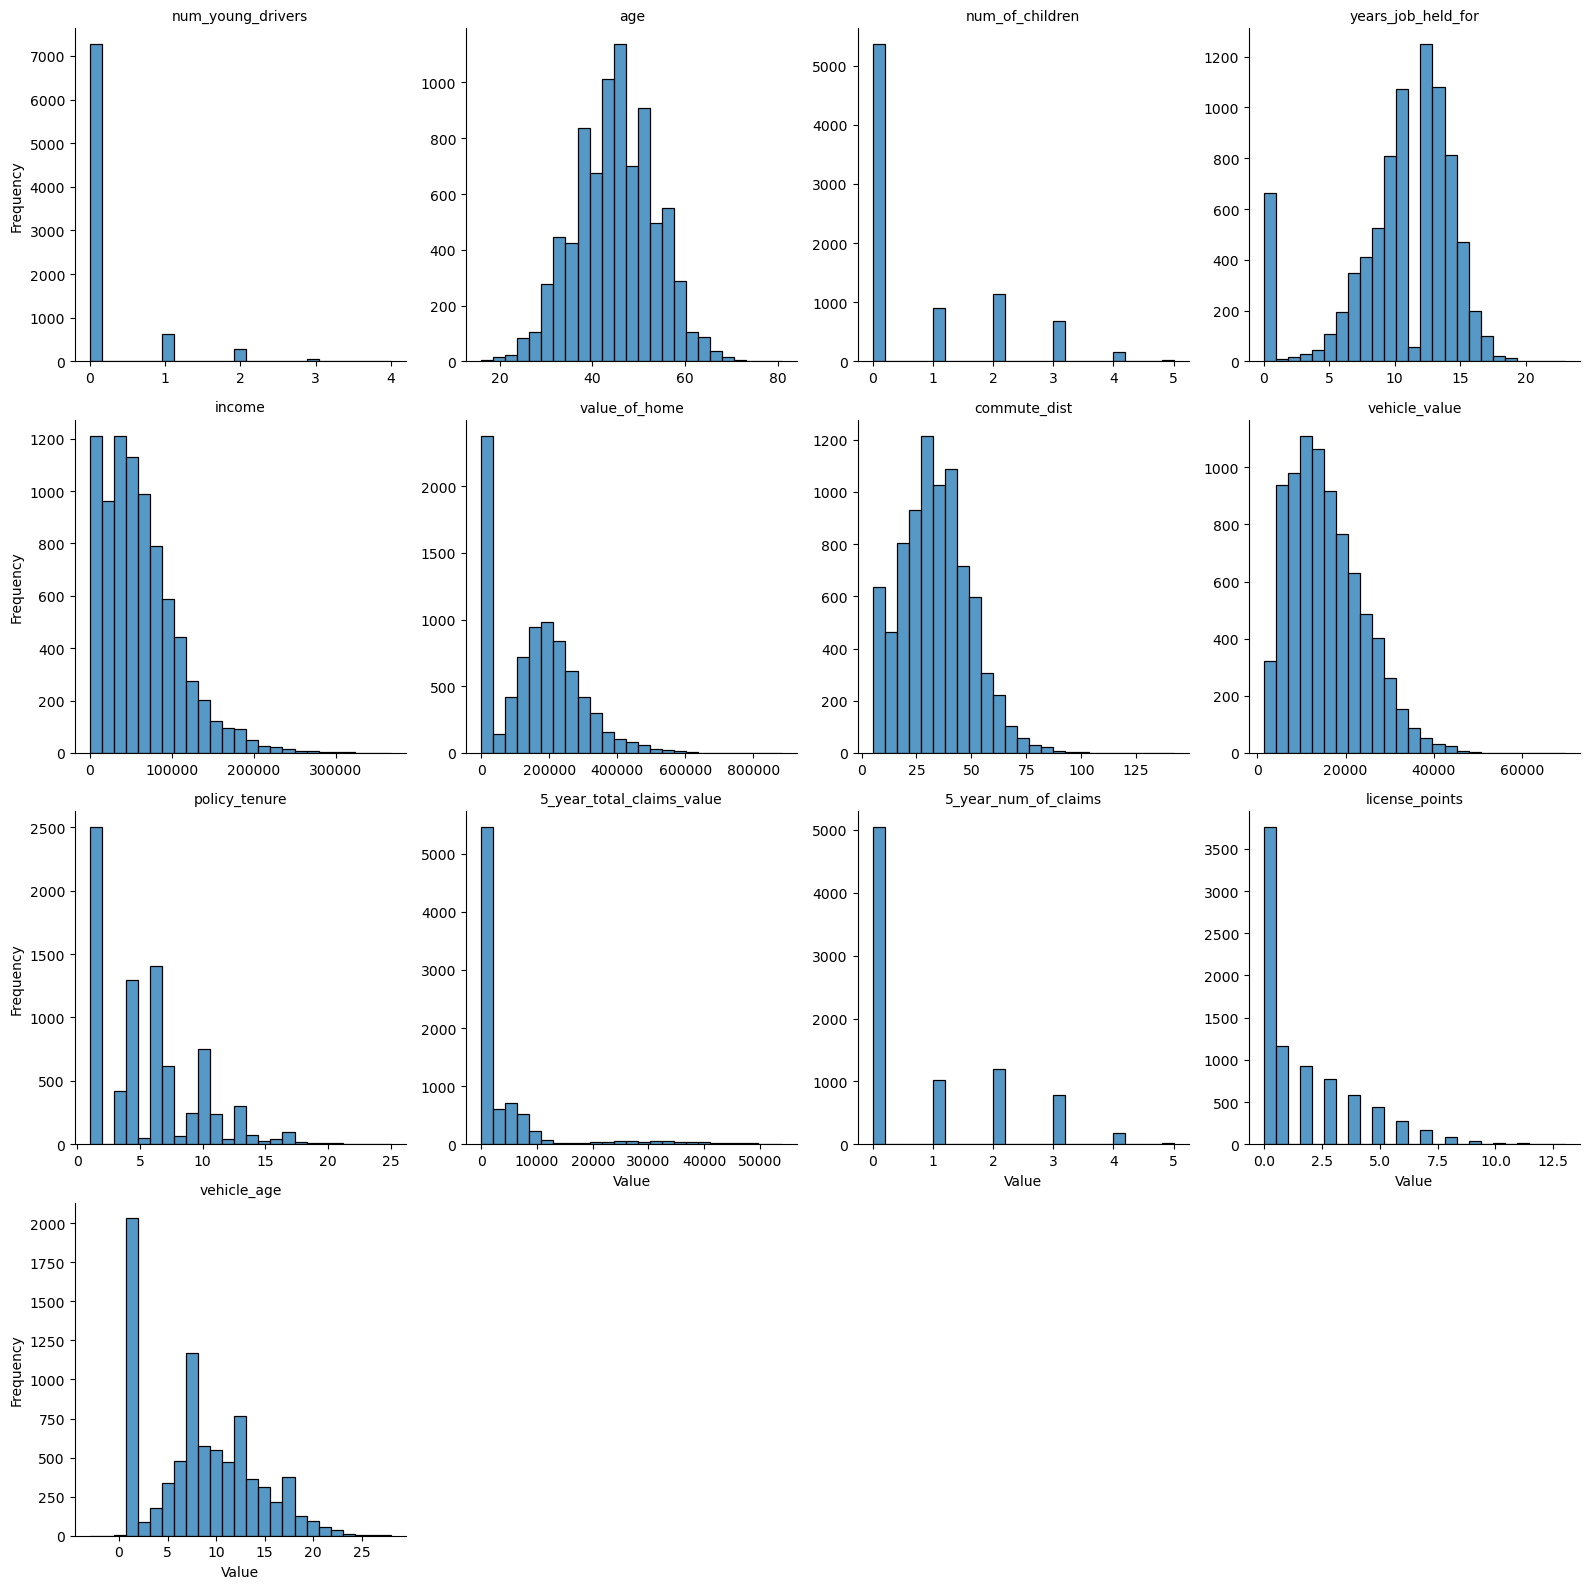

In [61]:
melted_X_train = final_train_df[numerical_cols].melt(var_name='Column', value_name='Value')

# create facetgrid(4 columns, 4 rows, height=4)
g = sns.FacetGrid(
    melted_X_train, col='Column', col_wrap=4,
    sharex=False, sharey=False, height=4
)

# draw each histogram in its facet (25 bins)
g.map(sns.histplot, 'Value', bins=25)

g.set_axis_labels('Value', 'Frequency')
g.set_titles(col_template='{col_name}')
plt.tight_layout(); plt.show()


In [62]:
# define features we want to skew

skewed_features = ['income', 'value_of_home', 'commute_dist', 'vehicle_value', 'policy_tenure', 'license_points']

from scipy.stats import skew

def log_of_features(data_df, skewed_features):
    data = data_df.copy()
    for feature in skewed_features:
        data[feature] = np.sqrt(data[feature])
    return data

final_train_df_cleaned_log = log_of_features(final_train_df, skewed_features)

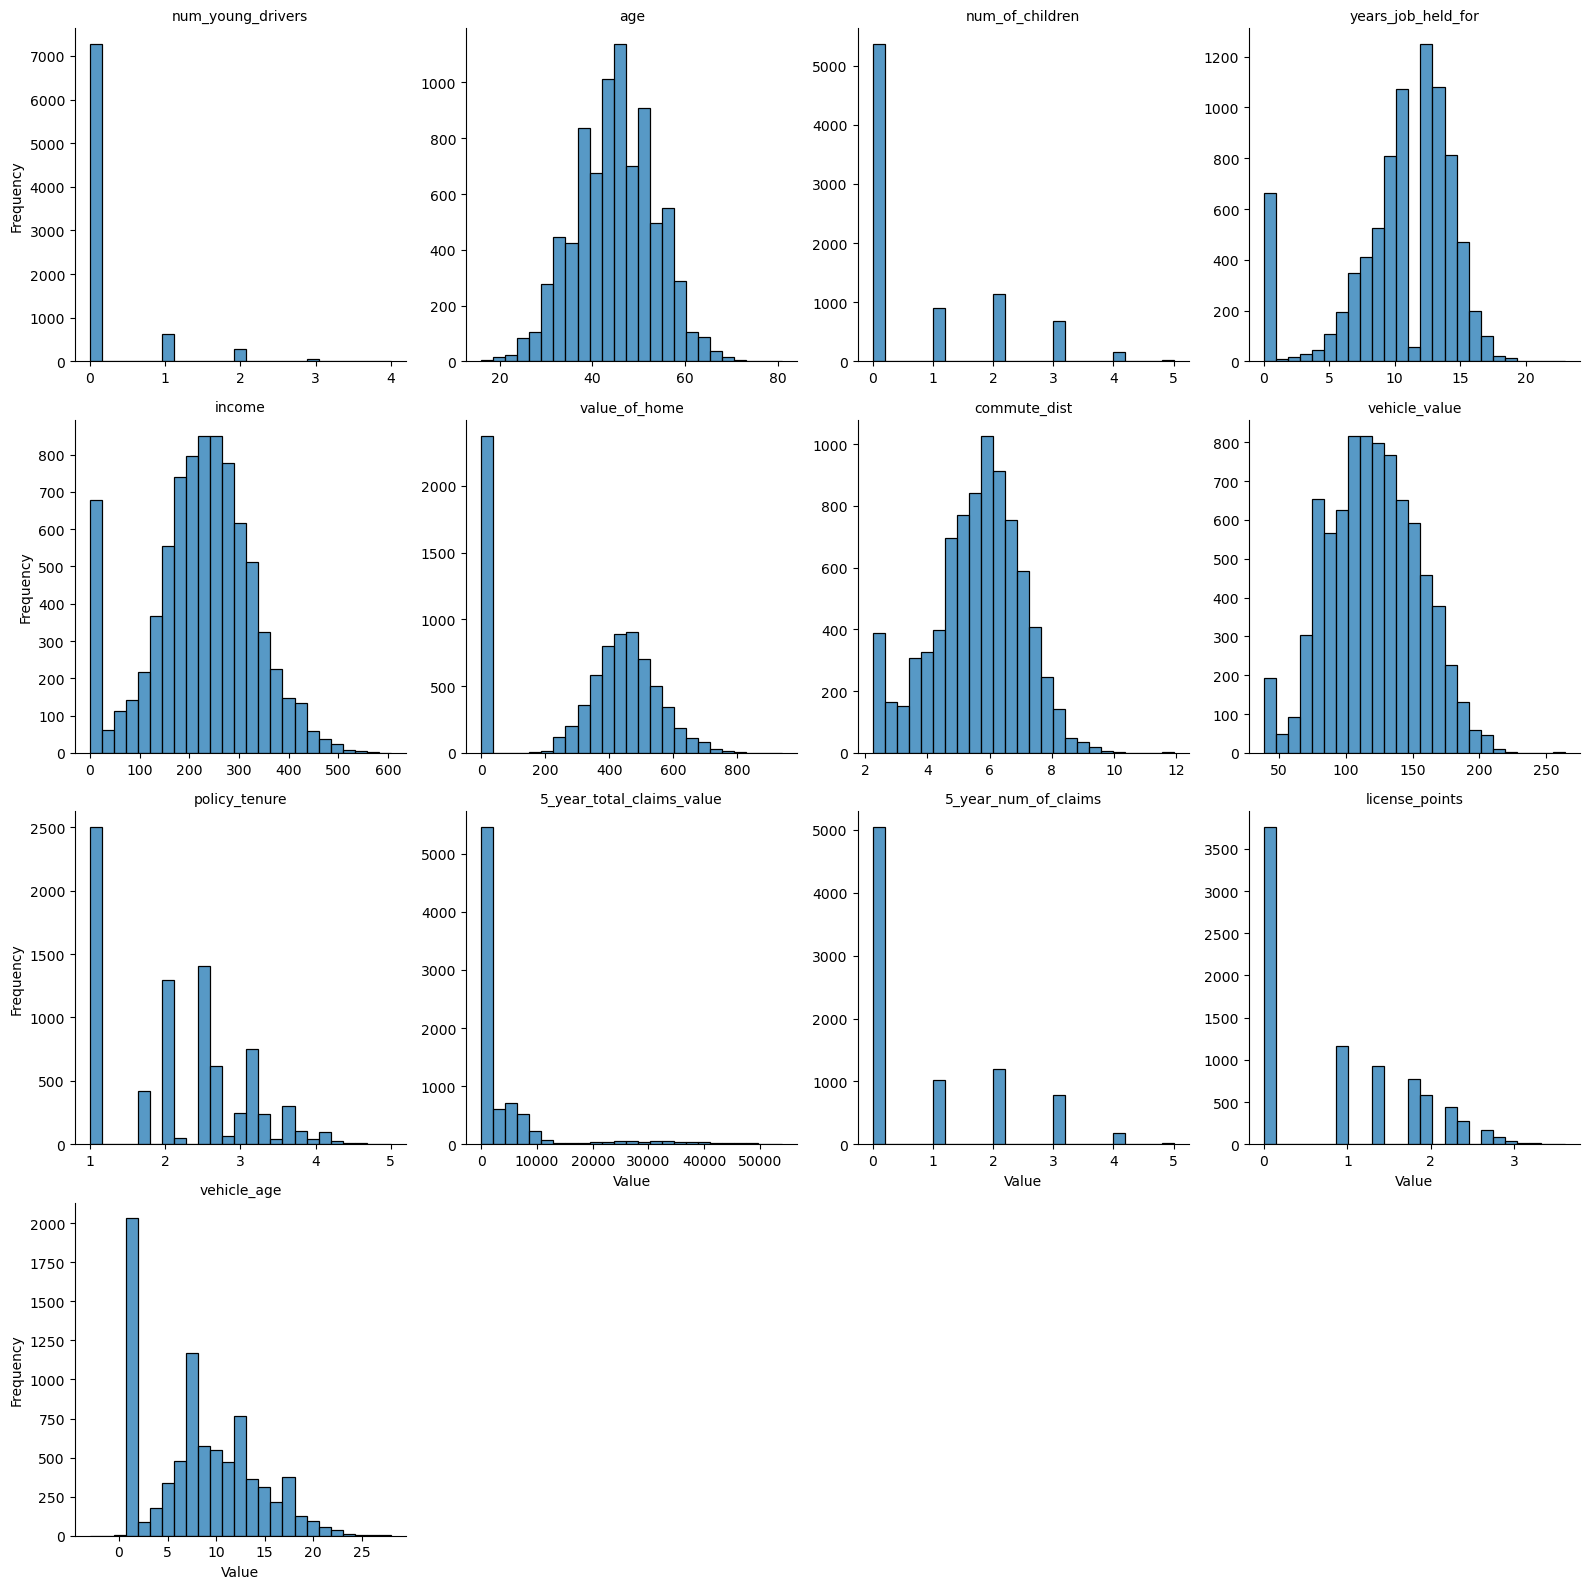

In [63]:
melted_X_train = final_train_df_cleaned_log[numerical_cols].melt(var_name='Column', value_name='Value')

# create facetgrid(4 columns, 4 rows, height=4)
g = sns.FacetGrid(
    melted_X_train, col='Column', col_wrap=4,
    sharex=False, sharey=False, height=4
)

# draw each histogram in its facet (25 bins)
g.map(sns.histplot, 'Value', bins=25)

g.set_axis_labels('Value', 'Frequency')
g.set_titles(col_template='{col_name}')
plt.tight_layout(); plt.show()


In [66]:
cat_boost_clf = CatBoostClassifier(random_state=42, verbose=0)

cv_scores = cross_val_score(cat_boost_clf, final_train_df, y_train, cv = k_fold)
cv_scores_log = cross_val_score(cat_boost_clf, final_train_df_cleaned_log, y_train, cv = k_fold)

print(f'CatBoost Classifier CV Accuracy (original data): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'CatBoost Classifier CV Accuracy (log transformed data): {cv_scores_log.mean():.4f} +/- {cv_scores_log.std():.4f}')

CatBoost Classifier CV Accuracy (original data): 0.7944 +/- 0.0180
CatBoost Classifier CV Accuracy (log transformed data): 0.7944 +/- 0.0180


In [67]:
## feauture scaling
from sklearn.preprocessing import StandardScaler

def scale_features(data_df, numeric_features):
    data = data_df.copy()
    scaler = StandardScaler()
    scaler.fit(data[numeric_features])
    data[numeric_features] = scaler.fit_transform(data[numeric_features])
    return data

scaled_final_train_df = scale_features(final_train_df_cleaned_log, numerical_cols)

In [68]:
cat_boost_clf = CatBoostClassifier(random_state=42, verbose=0)

cv_scores_scaled = cross_val_score(cat_boost_clf, scaled_final_train_df, y_train, cv = k_fold)
cv_scores = cross_val_score(cat_boost_clf, final_train_df, y_train, cv = k_fold)

print(f'CatBoost Classifier CV Accuracy (scaled data): {cv_scores_scaled.mean():.4f} +/- {cv_scores_scaled.std():.4f}') 
print(f'CatBoost Classifier CV Accuracy (original data): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

CatBoost Classifier CV Accuracy (scaled data): 0.7944 +/- 0.0180
CatBoost Classifier CV Accuracy (original data): 0.7944 +/- 0.0180


In [69]:
X_train_cleaned = scaled_final_train_df.copy()

### 7. Model Pipeline

#### 7.1 Custom Transformer


In [70]:
from sklearn.base import BaseEstimator, TransformerMixin

class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop(columns=self.columns_to_drop)
    
    def get_feature_names_out(self, input_features=None):
        return None

In [71]:
class SqrtTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_transform):
        self.columns_to_transform = columns_to_transform
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X[self.columns_to_transform] = np.sqrt(X[self.columns_to_transform])
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features

#### 7.2 Pipeline


In [ ]:
from sklearn import set_config

# Set transformer output to df so we can reference columns names
set_config(transform_output='pandas')